In [1]:
import numpy as np
import cv2
from pyproj import Transformer
from my_vbr_utils.vbr_dataset import vbrInterpolatedDataset, load_calibration, get_paths_from_scene
from my_vbr_utils.utilities import load_scene_correspondences
from my_utils.plotting import show_image_pair
# --- Config and Dataset Loading ---
# Set these variables to configure your scene and utility path
scene_name = 'ciampino_train0'
dataset_root_dir = "/datasets/vbr_slam"
calib_path = get_paths_from_scene(dataset_root_dir, scene_name)[-1]
calib = load_calibration(calib_path)

dataset = vbrInterpolatedDataset(dataset_root_dir,scene_name)
# print(model)

Loaded vbrInterpolatedDataset from scene:  ciampino_train0
Images loaded from:  /datasets/vbr_slam/ciampino/ciampino_train0_kitti/camera_left/data
Ground Truth Poses:  /datasets/vbr_slam/ciampino/ciampino_train0/ciampino_train0_gt.txt


In [2]:
# import ipywidgets as widgets
# from ipywidgets import interact, interactive, fixed, interact_manual
# from IPython.display import display
# import matplotlib.pyplot as plt
# import pandas as pd
# from PIL import Image
# # Assuming you have this function defined elsewhere in your notebook or in a module
# from my_utils.plotting import show_image_pair  # Replace with your actual import

# # Load the CSV file
# pairs_df = pd.read_csv('/home/bjangley/VPR/mast3r-v2/pairs_mining/ciampino_train0/ciampino_matches_inliers_fm_top3_anchors_per_query.csv')

# # Define the inlier ranges you're interested in
# inlier_ranges = [(i, i + 200) for i in range(200, 1800, 200)]


# # Create a dictionary to store the selected queries and their anchors
# selected_queries = {}

# # Iterate through the inlier ranges
# for i, (min_inliers, max_inliers) in enumerate(inlier_ranges):
#     # Filter the DataFrame for the current inlier range
#     filtered_df = pairs_df[(pairs_df['num_inliers'] >= min_inliers) & (pairs_df['num_inliers'] < max_inliers)]
    
#     # If there are any pairs in the current range, select the first query and all its anchors
#     if not filtered_df.empty:
#         # Get the first query_idx in the filtered DataFrame
#         query_idx = filtered_df['query_idx'].iloc[0]
        
#         # Get all rows (anchor-query pairs) associated with this query_idx
#         query_pairs_df = pairs_df[pairs_df['query_idx'] == query_idx]
        
#         # Store the query_idx and its associated anchor pairs in the dictionary
#         selected_queries[f'range_{i}'] = {
#             'query_idx': query_idx,
#             'anchor_pairs': query_pairs_df
#         }
#         # print(f"Found query {query_idx} with pairs in range {min_inliers}-{max_inliers-1} inliers")
#     else:
#         print(f"No queries found in range {min_inliers}-{max_inliers-1} inliers")

# # # Print the selected queries and their anchor pairs
# # print("\nSelected Queries and Anchor Pairs:")
# # for key, value in selected_queries.items():
# #     print(f"\n{key}:")
# #     print(f"  Query Index: {value['query_idx']}")
# #     print("  Anchor Pairs:")
# #     print(value['anchor_pairs'])
# # Function to display query and anchor images for a given range
# def display_images_for_range(range_index):
#     if 0 <= range_index < len(inlier_ranges):
#         min_inliers, max_inliers = inlier_ranges[range_index]
#         filtered_df = pairs_df[(pairs_df['num_inliers'] >= min_inliers) & (pairs_df['num_inliers'] < max_inliers)]

#         if not filtered_df.empty:
#             # Select up to 3 queries from the filtered DataFrame
#             num_queries_to_display = min(3, filtered_df['query_idx'].nunique())
#             query_idxs = filtered_df['query_idx'].unique()[:num_queries_to_display]

#             # Create a single figure with enough subplots
#             fig, axes = plt.subplots(len(query_idxs), 2, figsize=(10, 5*len(query_idxs)))  # 2 columns: Query and Anchor
#             if len(query_idxs) == 1:
#                 axes = [axes]

#             fig.suptitle(f"Inlier Range: {min_inliers}-{max_inliers-1}")

#             for i, query_idx in enumerate(query_idxs):
#                 # Get the first anchor-query pair for this query_idx within the inlier range
#                 query_pairs_df = filtered_df[filtered_df['query_idx'] == query_idx].iloc[[0]]

#                 # Load and display the query image
#                 query = dataset[int(query_idx)]
#                 query_img = Image.open(query['image'])
#                 axes[i,0].imshow(query_img)
#                 axes[i,0].set_title(f"Query {query_idx}")
#                 axes[i,0].axis('off')  # Hide axes

#                 # Load and display the anchor image
#                 index, row = query_pairs_df.iterrows().__next__()  # Get the first row
#                 anchor_idx = int(row['anchor_idx'])
#                 anchor = dataset[anchor_idx]
#                 anchor_img = Image.open(anchor['image'])

#                 num_matches = row['num_matches']
#                 num_inliers = row['num_inliers']
#                 axes[i,1].imshow(anchor_img)
#                 axes[i,1].set_title(f"Anchor {anchor_idx}\nMatches: {num_matches}, Inliers: {num_inliers}")
#                 axes[i,1].axis('off')

#             plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle
#             plt.show()
#         else:
#             print(f"No queries found in range {min_inliers}-{max_inliers-1} inliers")
#     else:
#         print("Invalid range index")

# # Create an interactive slider
# range_slider = widgets.IntSlider(
#     min=0,
#     max=len(inlier_ranges) - 1,
#     step=1,
#     value=0,
#     description='Inlier Range:'
# )

# # Use interact to connect the slider to the display function
# interact(display_images_for_range, range_index=range_slider)

In [3]:
### LOAD MAST3R MODEL AND INFERENCE UTILITIES
from mast3r.model import AsymmetricMASt3R
#load model
device = 'cuda:7'

# CHECKPOINT = "naver/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric"
CHECKPOINT="/home/bjangley/VPR/mast3r-v2/checkpoints_v2/ciampino_train0_ciampino_train1_lr6/checkpoint-10.pth"
model = AsymmetricMASt3R.from_pretrained(CHECKPOINT).to(device)

... loading model from /home/bjangley/VPR/mast3r-v2/checkpoints_v2/ciampino_train0_ciampino_train1_lr6/checkpoint-10.pth
instantiating : AsymmetricMASt3R(
patch_embed_cls='PatchEmbedDust3R',
img_size=(512,512),
enc_depth=24,
dec_depth=12,
enc_embed_dim=1024,
dec_embed_dim=768,
enc_num_heads=16,
dec_num_heads=12,
pos_embed='RoPE100',
head_type='catmlp+dpt',
output_mode='pts3d+desc24',
depth_mode=('exp',-inf,inf),
conf_mode=('exp',1,inf),
two_confs=True,
desc_conf_mode=('exp',0,inf),
landscape_only=False
)
<All keys matched successfully>


/home/bjangley/VPR/mast3r-v2/dust3r/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/home/bjangley/VPR/mast3r-v2/dust3r/dust3r/model.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/bjangley/VPR/mast3r-v2/dust3r/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


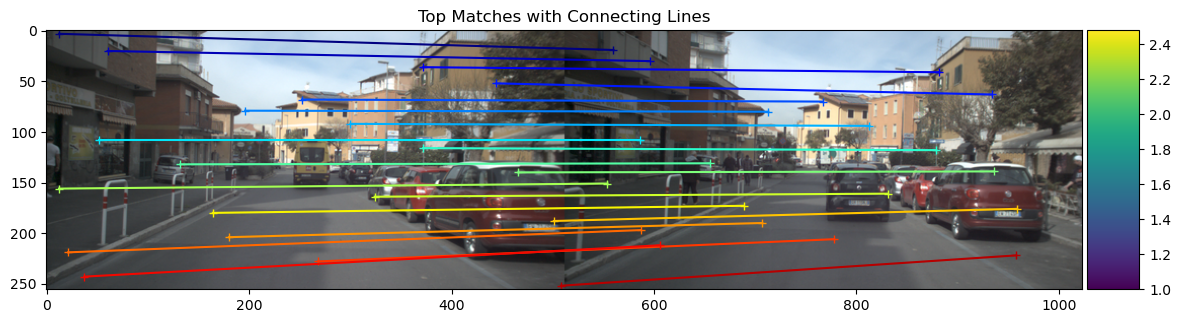

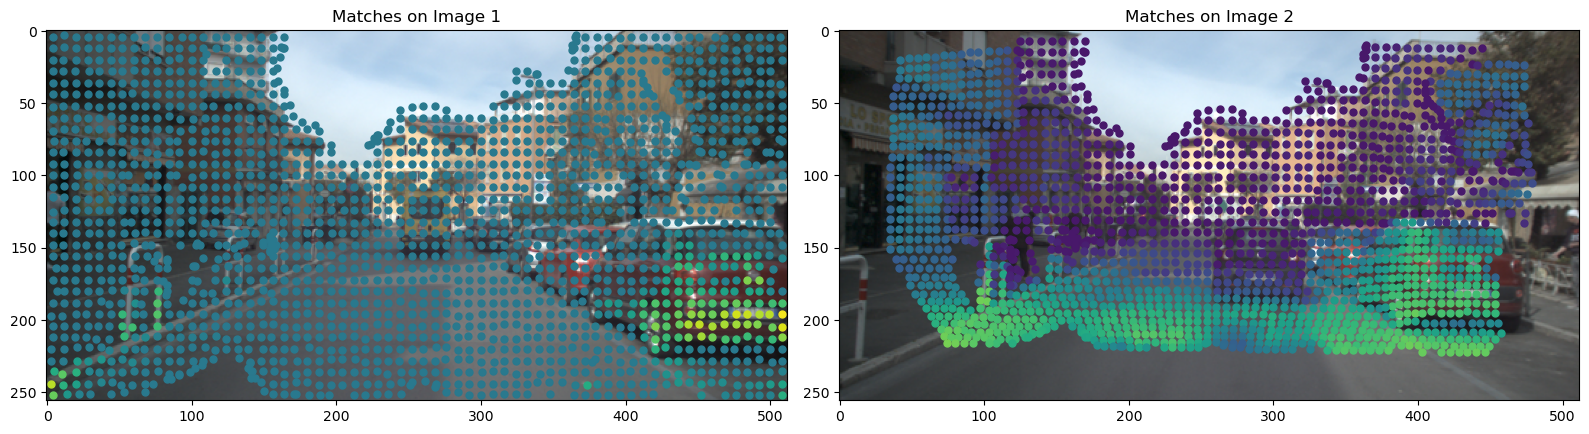

Fundamental matrix: 1894 matches, 1674 inliers, 220 outliers
Mast3r image shape:  256 512


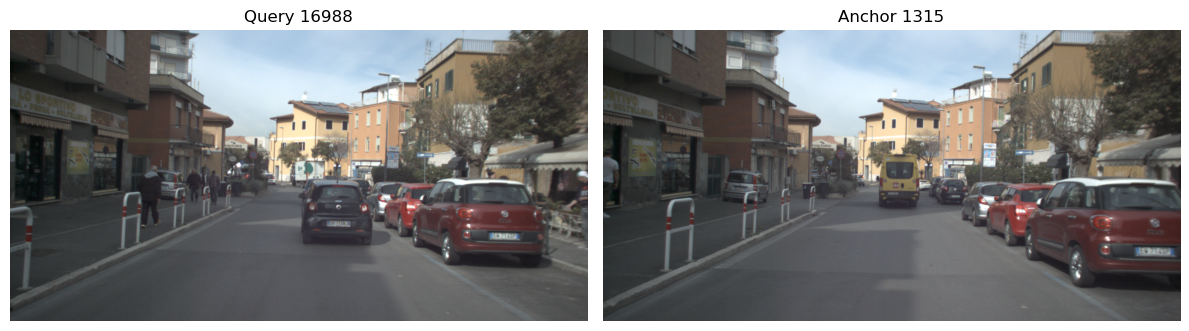

In [4]:
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as Rscipy
from my_utils.mast3r_utils import get_master_output, get_mast3r_image_shape,scale_intrinsics,overlap,plot_depth_overlay_on_image,plot_lidar_mast3r_matches
from my_utils.my_vbr_dataset import generate_depth_and_scene_maps
from my_utils.mast3r_utils import recompute_intrinsics
# --- Load anchor-query pair ---
pairs_df = pd.read_csv('/home/bjangley/VPR/mast3r-v2/pairs_mining/ciampino_train0/ciampino_matches_inliers_fm_top3_anchors_per_query.csv')
# row = pairs_df.iloc[295]
row = pairs_df.iloc[450]
# row = pairs_df.iloc[130]
# row = pairs_df.iloc[70]

anchor_idx, query_idx = int(row['anchor_idx']), int(row['query_idx'])
anchor = dataset[anchor_idx]
query  = dataset[query_idx]
gt_pose = query['pose']

# --- Run MASt3R model and extract matches ---
output = get_master_output(
    model, device,
    anchor['image'],
    query['image'],
    visualize=True,
    verbose=False
)
matches_im0 = output[0]
matches_im1 = output[1]
pts3d_im0   = output[2]


# --- find number of inliers from the matches ---
if len(matches_im0) >= 8:
    F, mask_f = cv2.findFundamentalMat(matches_im0, matches_im1, cv2.FM_RANSAC, 1, 0.99)
    num_inliers_f = int(mask_f.sum()) if mask_f is not None else 0
    inlier_mask = mask_f.ravel().astype(bool)
    inlier_im0 = matches_im0[inlier_mask]
    inlier_im1 = matches_im1[inlier_mask]
else:
    num_inliers_f = 0
    inlier_im0 = np.empty((0, 2))
    inlier_im1 = np.empty((0, 2))
print(f"Fundamental matrix: {len(matches_im0)} matches, {num_inliers_f} inliers, {len(matches_im0) - num_inliers_f} outliers")

T_cam_lidar = calib['cam_l']['T_cam_lidar']
K = calib['cam_l']['K']
# --- LiDAR projection and image resizing ---
img = cv2.imread(anchor['image'])
H, W = img.shape[:2]
mast3r_w, mast3r_h = get_mast3r_image_shape(W, H)
print("Mast3r image shape: ", mast3r_h, mast3r_w)
# K_new = scale_intrinsics(K, W, H, mast3r_w, mast3r_h)
K_new = recompute_intrinsics(K,(W,H),size=512)
depth_map, scene_map = generate_depth_and_scene_maps(anchor['lidar_points'], K_new, T_cam_lidar, (mast3r_h, mast3r_w))

# --- Load and show anchor/query images ---
anchor_img = Image.open(anchor['image'])
query_img = Image.open(query['image'])
show_image_pair(anchor_img, query_img, anchor_idx, query_idx)

# --- LiDAR depth overlay ---
img_orig = plt.imread(anchor['image'])
img_resized = cv2.resize(img_orig, (mast3r_w, mast3r_h))
img_resized = img_resized.astype(np.float32) / 255.0 if img_resized.dtype == np.uint8 else img_resized
v, u = np.where(np.isfinite(depth_map))
pixel_uv = np.stack((u, v), axis=-1)



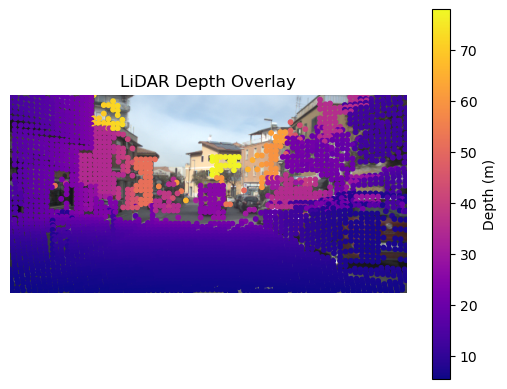

In [5]:
from my_utils.mast3r_utils import plot_depth_overlay_on_image
v, u = np.where(np.isfinite(depth_map))
pixel_uv = np.stack((u, v), axis=-1)
plot_depth_overlay_on_image(img_resized, scene_map, pixel_uv, point_size=10, alpha=1.0, title="LiDAR Depth Overlay")


3049
Min depth: 5.459062613317399, Max depth: 77.97083376079054


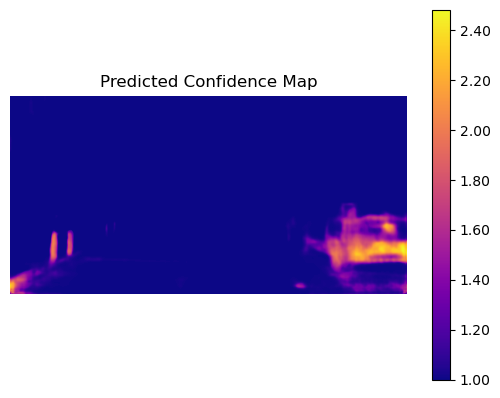

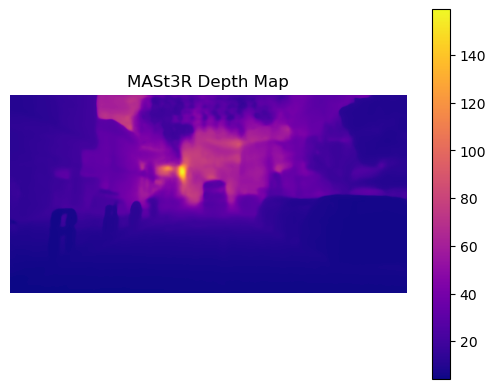

Total elements in scene_map: 393216
Number of NaN values: 384069
Percentage of NaN values: 97.67%


In [6]:
print(len(u))
depth_min = np.nanmin(depth_map[np.isfinite(depth_map)])
depth_max = np.nanmax(depth_map[np.isfinite(depth_map)])


print(f"Min depth: {depth_min}, Max depth: {depth_max}")
conf_im0 = output[4]

plt.imshow(conf_im0, cmap='plasma')
plt.title("Predicted Confidence Map")
cbar = plt.colorbar(format='%.2f')
plt.axis('off') 
plt.show()


pts3d=output[2]
plt.imshow(pts3d[:,:,2], cmap='plasma') #, vmin = depth_min, vmax=depth_max
plt.title("MASt3R Depth Map")
plt.colorbar()
plt.axis('off') 
plt.show()

total_elements = scene_map.size
nan_count = np.sum(np.isnan(scene_map))
nan_percentage = (nan_count / total_elements) * 100

print(f"Total elements in scene_map: {total_elements}")
print(f"Number of NaN values: {nan_count}")
print(f"Percentage of NaN values: {nan_percentage:.2f}%")


[0.36294547 0.08011364 2.14767652] [1.01887296 0.30864283 3.93716811]
Mean L2 Depth Error: 4.1842
Median L2 Depth Error: 2.2969
Std L2 Depth Error: 5.6431


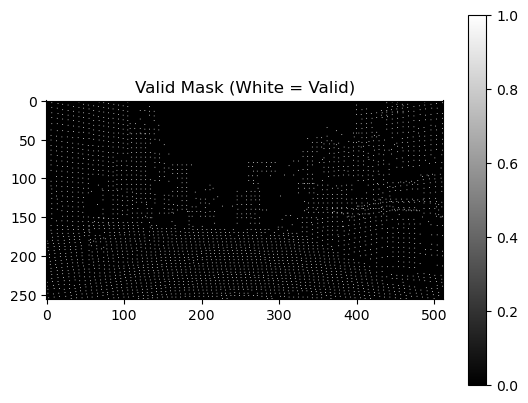

Number of valid elements: 3049
Total elements: 131072
Percentage of valid elements: 2.33%
Number of valid lidar in depth map: 3049


In [7]:
# 2. Find valid comparison pixels (where both have valid depth)
valid_mask = np.isfinite(scene_map).all(axis=2) & np.isfinite(pts3d_im0).all(axis=2)
finite_mask = np.isfinite(depth_map) 
# positive_mask = depth_map > 0
# valid_mask = finite_mask & positive_mask

# 3. Vector depth error
depth_error = np.abs(pts3d_im0[valid_mask] - scene_map[valid_mask])

# 4. Calculate statistics of the error
mean_depth_error = np.median(depth_error, axis=0)
std_depth_error = np.std(depth_error, axis=0)
max_depth_error = np.mean(depth_error, axis=0)
print(mean_depth_error, max_depth_error)

# 5. Calculate L2 norm error
l2_depth_error = np.linalg.norm(pts3d_im0[valid_mask] - scene_map[valid_mask], axis=-1)

# 6. Calculate statistics of the L2 norm error
mean_l2_error = np.mean(l2_depth_error)
median_l2_error = np.median(l2_depth_error)
std_l2_error = np.std(l2_depth_error)

print(f"Mean L2 Depth Error: {mean_l2_error:.4f}")
print(f"Median L2 Depth Error: {median_l2_error:.4f}")
print(f"Std L2 Depth Error: {std_l2_error:.4f}")

# --- Visualize the valid mask ---
plt.imshow(finite_mask, cmap='gray')  # Display the mask as a grayscale image
plt.title("Valid Mask (White = Valid)")
plt.colorbar()
plt.show()

# --- Count the number of valid elements ---
num_valid_elements = np.sum(valid_mask)
print(f"Number of valid elements: {num_valid_elements}")
total_elements = valid_mask.size
print(f"Total elements: {total_elements}")
print(f"Percentage of valid elements: {(num_valid_elements / total_elements) * 100:.2f}%")
print(f"Number of valid lidar in depth map: {len(u)}")



In [8]:
# Compute all localizations for the loaded anchor-query pair

from my_utils.scaling import compute_scaled_points
from my_utils.transformations import se3_to_pose, pose_to_se3
from my_utils.mast3r_utils import solve_pnp

T_base_cam = calib['cam_l']['T_base_cam']

# --- Prepare inlier 3D-2D correspondences ---
if len(inlier_im0) >= 4:
    mast3r_pts = pts3d_im0[inlier_im0[:, 1].astype(int), inlier_im0[:, 0].astype(int)]
    inlier_2d = inlier_im1.astype(np.float32)
else:
    mast3r_pts = np.empty((0, 3))
    lidar_pts = np.empty((0, 3))
    inlier_2d = np.empty((0, 2))

T_anchor_local = pose_to_se3(anchor['pose'])
T_query_local =  pose_to_se3(query['pose'])
pose_query = se3_to_pose(T_query_local)
pose_anchor = se3_to_pose(T_anchor_local)
# --- PnP from MASt3R ---
print(len(inlier_2d))
T_query_anchor_mast3r = solve_pnp(mast3r_pts, inlier_2d, K_new) if len(mast3r_pts) >= 4 else None
if T_query_anchor_mast3r is not None:
    T_m_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_mast3r)
    pose_m = se3_to_pose(T_m_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

# --- PnP from MASt3R (Close Predictions Only) ---
max_distance = 40  # Define maximum distance threshold (in meters)
close_mask = np.linalg.norm(mast3r_pts, axis=1) < max_distance
close_mast3r_pts = mast3r_pts[close_mask]
close_inlier_2d = inlier_2d[close_mask]

T_query_anchor_mast3r_close = solve_pnp(close_mast3r_pts, close_inlier_2d, K_new) if len(close_mast3r_pts) >= 4 else None
if T_query_anchor_mast3r_close is not None:
    T_m_local_close = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_mast3r_close)
    pose_m_close = se3_to_pose(T_m_local_close)
else:
    pose_m_close = None  # Or some default invalid pose


matched_uv, matched_lidar_uv, matched_indices = overlap(inlier_im0, depth_map, max_pixel_dist=2)
inlier_im0 = inlier_im0[matched_indices]
inlier_im1 = inlier_im1[matched_indices]
lidar_pts = scene_map[matched_lidar_uv[:, 1].astype(int), matched_lidar_uv[:, 0].astype(int)]
mast3r_pts2 = pts3d_im0[inlier_im0[:, 1].astype(int), inlier_im0[:, 0].astype(int)]
inlier_2d = inlier_im1.astype(np.float32)
# --- PnP from LiDAR ---
print(len(matched_indices))
T_query_anchor_lidar = solve_pnp(lidar_pts, inlier_2d, K_new) if len(lidar_pts) >= 4 else None
if T_query_anchor_lidar is not None:
    T_l_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_lidar)
    pose_l = se3_to_pose(T_l_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]


# --- MASt3R scaled v3 (L1 centroid scale) ---
mast3r_pts_scaled_v3, scale_v3 = compute_scaled_points('v3', mast3r_pts2, lidar_pts) if len(mast3r_pts) >= 4 and len(lidar_pts) >= 4 else (np.empty((0, 3)), None)
if scale_v3 is not None:
    print(f"Scale estimated for v3 (L1 centroid scale): {scale_v3}")
T_query_anchor_scaled_v3 = solve_pnp(mast3r_pts_scaled_v3, inlier_2d, K_new) if mast3r_pts_scaled_v3.size > 0 else None
if T_query_anchor_scaled_v3 is not None:
    T_s3_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_scaled_v3)
    pose_s3 = se3_to_pose(T_s3_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

# --- MASt3R scaled v4 (per-axis L1 scale) ---
mast3r_pts_scaled_v4, scale_v4 = compute_scaled_points('v4', mast3r_pts2, lidar_pts) if len(mast3r_pts) >= 4 and len(lidar_pts) >= 4 else (np.empty((0, 3)), None)
if scale_v4 is not None:
    print(f"Scale estimated for v4 (per-axis L1 scale): {scale_v4}")
T_query_anchor_scaled_v4 = solve_pnp(mast3r_pts_scaled_v4, inlier_2d, K_new) if mast3r_pts_scaled_v4.size > 0 else None
if T_query_anchor_scaled_v4 is not None:
    T_s4_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_scaled_v4)
    pose_s4 = se3_to_pose(T_s4_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

# --- MASt3R scaled ICP (Umeyama) ---
mast3r_pts_scaled_icp, scale_icp = compute_scaled_points('icp', mast3r_pts2, lidar_pts) if len(mast3r_pts) >= 4 and len(lidar_pts) >= 4 else (np.empty((0, 3)), None)
if scale_icp is not None:
    print(f"Scale estimated for ICP (Umeyama): {scale_icp}")
T_query_anchor_scaled_icp = solve_pnp(mast3r_pts_scaled_icp, inlier_2d, K_new) if mast3r_pts_scaled_icp.size > 0 else None
if T_query_anchor_scaled_icp is not None:
    T_icp_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_scaled_icp)
    pose_icp = se3_to_pose(T_icp_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

1674
493
Scale estimated for v3 (L1 centroid scale): 1.1659791421010333
Scale estimated for v4 (per-axis L1 scale): [1.0019742 0.9831978 1.2609885]
Scale estimated for ICP (Umeyama): 1.0283151669855055


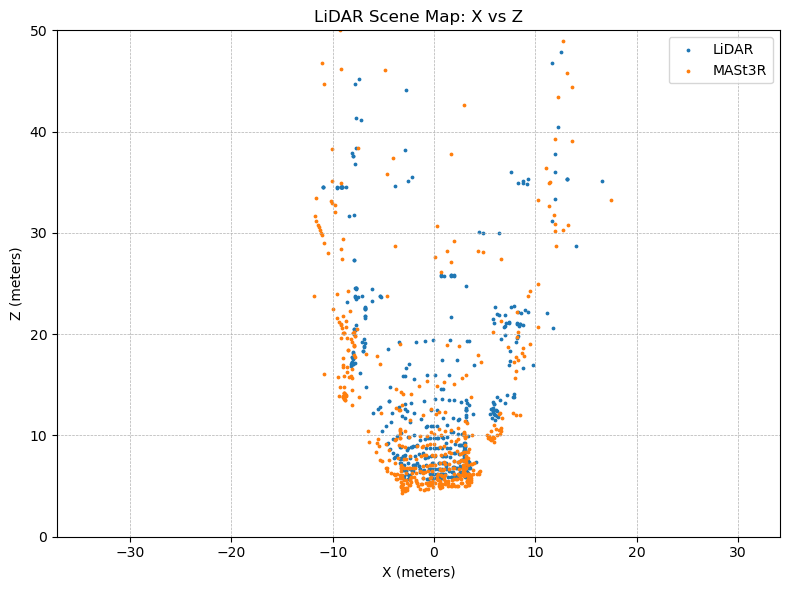

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(scene_map[matched_lidar_uv[:, 1].astype(int), matched_lidar_uv[:, 0].astype(int), 0], scene_map[matched_lidar_uv[:, 1].astype(int), matched_lidar_uv[:, 0].astype(int), 2], s=3, label="LiDAR")
plt.scatter(pts3d_im0[inlier_im0[:, 1].astype(int), inlier_im0[:, 0].astype(int), 0], pts3d_im0[inlier_im0[:, 1].astype(int), inlier_im0[:, 0].astype(int), 2], s=3, label="MASt3R")
plt.xlabel('X (meters)')
plt.ylabel('Z (meters)')
plt.title('LiDAR Scene Map: X vs Z')
plt.legend()
plt.axis('equal')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim([0,50])
plt.tight_layout()
plt.show()

GT Query [199.16462685659968, 45.34590280309113, 4.30531654776783, 0.07087696078344984, -0.06700796412278867, 0.6949707662202164, 0.7123917624969465]
GT Anchor [199.27281195232388, 47.4556683291346, 4.692000861575961, 0.07252802484314333, -0.0623350230126924, 0.693583228480556, 0.7140002350761857]
MASt3R Estimate [199.5750801291142, 43.586601561647285, 3.365216721307151, -0.6373974767097788, -0.02264767910789438, 0.025326131165188344, 0.7697857665579669]
MASt3R Estimate Close [199.60933277928822, 43.53108358263028, 3.189326724016357, -0.6315274567276181, -0.0255007046485613, 0.024398011343527114, 0.7745498838061073]
LiDAR Estimate [198.93685447612145, 45.63164473822661, 3.664936432025652, -0.6369891438279409, 0.007332232314081367, -0.0047139738779604645, 0.7708234865810182]


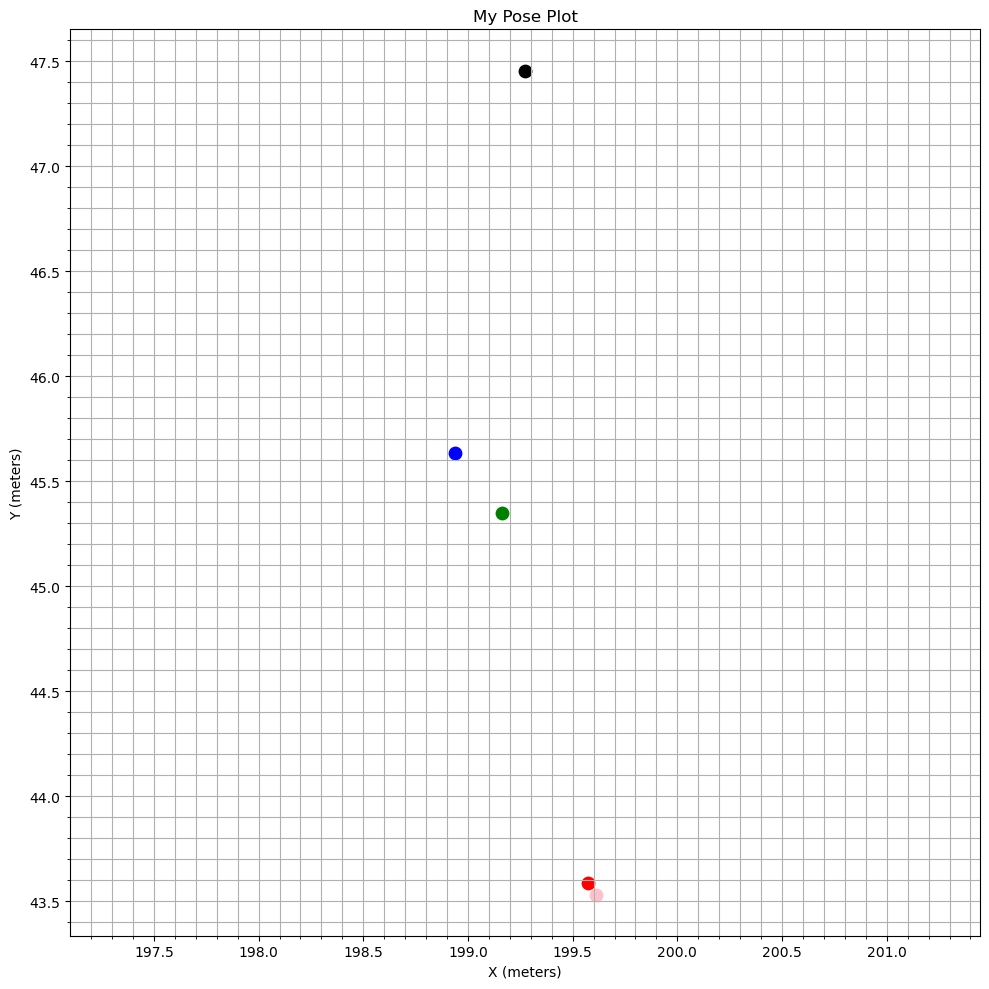

In [10]:
def plot_poses(poses, colors, labels, title="Pose Plot", xlabel="X (meters)", ylabel="Y (meters)"):
    """
    Plots poses on a 2D plane with specified colors and labels.

    Args:
        poses (dict): A dictionary where keys are labels and values are lists of poses (tx, ty, tz, qx, qy, qz, qw).
        colors (dict): A dictionary where keys are labels and values are colors for plotting.
        labels (list): A list of labels for the poses.
        title (str): The title of the plot.
        xlabel (str): The label for the x-axis.
        ylabel (str): The label for the y-axis.
    """
    import matplotlib.pyplot as plt
    from my_utils.transformations import se3_to_pose, pose_to_se3
    import numpy as np

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axis('equal')
    ax.grid(True, which='both')
    ax.minorticks_on()

    for label in labels:
        if label not in poses:
            print(f"Warning: Label '{label}' not found in poses dictionary.")
            continue

        if label not in colors:
            print(f"Warning: Label '{label}' not found in colors dictionary. Using default color 'blue'.")
            color = 'blue'
        else:
            color = colors[label]

        for i, pose in enumerate(poses[label]):
            print(label,pose)
            if pose is not None:
                T = pose_to_se3(pose)
                ax.scatter(T[0, 3], T[1, 3], c=color, marker='o', s=80, label=label if i == 0 else "")


    # Create custom legend without duplicates
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    # ax.legend(by_label.values(), by_label.keys(), loc='best')

    plt.tight_layout()
    plt.show()


from my_utils.transformations import se3_to_pose, pose_to_se3
import numpy as np


poses = {
    "GT Query": [pose_query],
    "GT Anchor": [pose_anchor],
    "MASt3R Estimate": [pose_m],
    "MASt3R Estimate Close": [pose_m_close],
    "LiDAR Estimate": [pose_l]

}
colors = {
    "GT Query": "green",
    "GT Anchor": "black",
    "MASt3R Estimate": "red",
    "MASt3R Estimate Close": "pink",
    "LiDAR Estimate": "blue"
}
labels = ["GT Query", "GT Anchor","MASt3R Estimate","MASt3R Estimate Close", "LiDAR Estimate"]
plot_poses(poses, colors, labels, title="My Pose Plot")

In [11]:
print(pose_query)
print(pose_anchor)

[199.16462685659968, 45.34590280309113, 4.30531654776783, 0.07087696078344984, -0.06700796412278867, 0.6949707662202164, 0.7123917624969465]
[199.27281195232388, 47.4556683291346, 4.692000861575961, 0.07252802484314333, -0.0623350230126924, 0.693583228480556, 0.7140002350761857]
